In [1]:
from matplotlib.widgets import Slider
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pydicom
import os

In [2]:
file_path = "/home/amina/amina/ws-bt-prelim/spring_04/test/DICOM/FLR_2020-01-07/MR.1.2.246.352.221.574001344182204027117355889133436477337.dcm"
ds = pydicom.dcmread(file_path)

In [3]:
ds

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 186
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.246.352.221.574001344182204027117355889133436477337
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.246.352.70.2.1.160.3
(0002,0013) Implementation Version Name         SH: 'DCIE 2.2'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 192'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'PROJECTION IMAGE', 'M', 'IR']
(0008,0012) Instance Creation Date              DA: '20220429'
(0008,0013) Instance Creation Time              TM: '135735'
(0008,0016) SOP Class UID                       UI: MR Image Storage
(0008,0018) SOP Inst

In [4]:
print("patient id:", ds.get("PatientID"))
print("modality:", ds.get("Modality"))
print("study date:", ds.get("InstanceCreationDate"))
print("image shape:", ds.pixel_array.shape)

patient id: RPRO01
modality: MR
study date: 20220429
image shape: (1024, 1024)


In [5]:
base_path = "/home/amina/amina/ws-bt-prelim/spring_04/test/DICOM"

slice_counts = []
modalities = []
shapes = []

In [6]:
for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    if not os.path.isdir(folder_path):
        continue
    
    dcm_files = [f for f in os.listdir(folder_path) if f.endswith(".dcm")]
    slice_counts.append(len(dcm_files))
    if len(dcm_files) == 0:
        continue
    
    sample_file = os.path.join(folder_path, dcm_files[0])
    ds = pydicom.dcmread(sample_file)
    
    modalities.append(ds.get("modality", "unknown"))
    shapes.append(ds.pixel_array.shape)

In [7]:
print("slice count distr:", Counter(slice_counts))
print("modalities:", Counter(modalities))
print("unique shapes:", set(shapes))

slice count distr: Counter({33: 11, 34: 4, 36: 3, 0: 1, 35: 1, 356: 1})
modalities: Counter({'unknown': 20})
unique shapes: {(528, 528), (512, 512), (432, 432), (288, 288), (1024, 1024)}


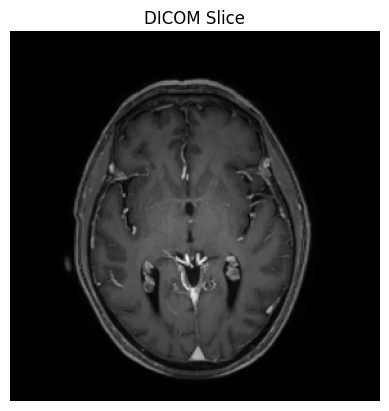

In [8]:
ds = pydicom.dcmread(sample_file)
plt.imshow(ds.pixel_array, cmap="gray")
plt.title("DICOM Slice")
plt.axis("off")
plt.show()

In [9]:
def load_dicom_volume(folder_path):
    slices = []
    
    for f in os.listdir(folder_path):
        if f.endswith(".dcm"):
            ds = pydicom.dcmread(os.path.join(folder_path, f))
            slices.append(ds)
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    volume = np.stack([s.pixel_array for s in slices])
    return volume

In [10]:
volume = load_dicom_volume(folder_path)
print("volume shape:", volume.shape)

volume shape: (34, 288, 288)


In [11]:
folder_path = "/home/amina/amina/ws-bt-prelim/spring_04/test/DICOM/FLR_2020-01-07"
volume = load_dicom_volume(folder_path)

In [12]:
%matplotlib widget

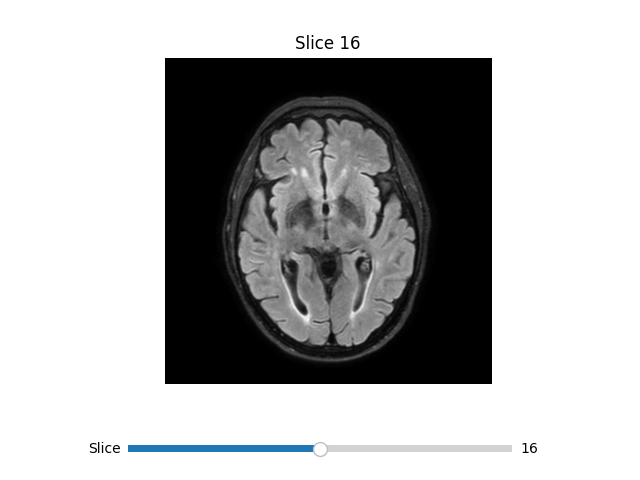

In [13]:
slice_idx = volume.shape[0] // 2

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.2)

img = ax.imshow(volume[slice_idx], cmap="gray")
ax.set_title(f"Slice {slice_idx}")
ax.axis("off")

ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
slider = Slider(ax_slider, "Slice", 0, volume.shape[0]-1, valinit=slice_idx, valstep=1)

def update(val):
    idx = int(slider.val)
    img.set_data(volume[idx])
    ax.set_title(f"Slice {idx}")
    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()